<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 846 | Val: 205 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 16, accumulation steps = 3 (effective batch size ≈ 48, tuned value = 48)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Using gradient accumulation: 3 micro-batches per optimizer step (effective batch size ≈ micro_batch x 3).


[DenseNet-121] Epoch   1/100 | LR: 3.44e-04 | train loss 1.0041 acc 0.589 | val loss 0.6797 acc 0.746 *


[DenseNet-121] Epoch   2/100 | LR: 3.44e-04 | train loss 0.5110 acc 0.743 | val loss 0.6124 acc 0.795 *


[DenseNet-121] Epoch   3/100 | LR: 3.44e-04 | train loss 0.5834 acc 0.720 | val loss 0.4624 acc 0.820 *


[DenseNet-121] Epoch   4/100 | LR: 3.44e-04 | train loss 0.4195 acc 0.792 | val loss 0.4812 acc 0.815


...

[DenseNet-121] Epoch  19/100 | LR: 3.44e-05 | train loss 0.0587 acc 0.975 | val loss 0.3486 acc 0.873


[DenseNet-121] Epoch  20/100 | LR: 3.44e-05 | train loss 0.0630 acc 0.973 | val loss 0.3583 acc 0.883


[DenseNet-121] Epoch  21/100 | LR: 3.44e-05 | train loss 0.0585 acc 0.974 | val loss 0.3603 acc 0.888


[DenseNet-121] Epoch  22/100 | LR: 3.44e-06 | train loss 0.0527 acc 0.981 | val loss 0.3608 acc 0.878


[DenseNet-121] Epoch  23/100 | LR: 3.44e-06 | train loss 0.0435 acc 0.980 | val loss 0.3712 acc 0.888

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 23.

[DenseNet-121] Restored best checkpoint (val loss = 0.3243)


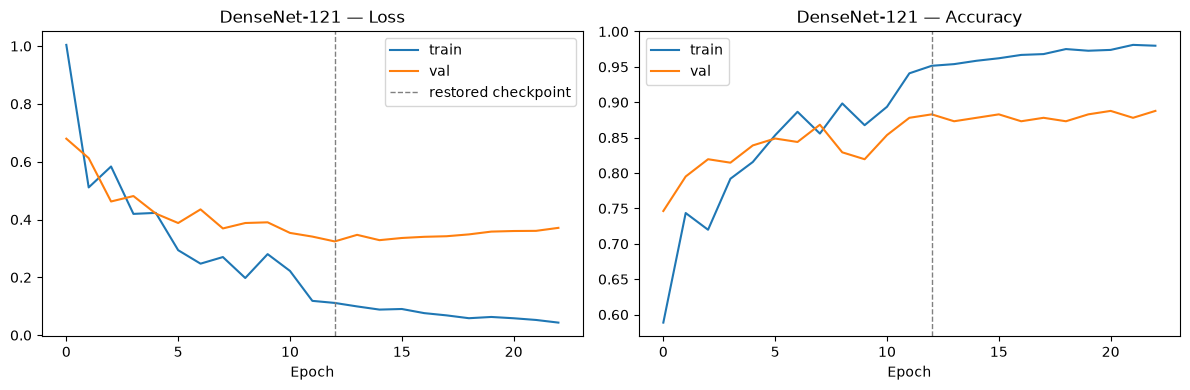

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.626


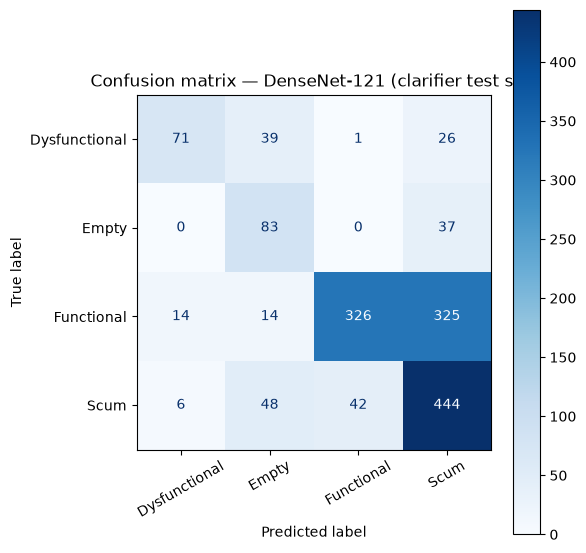

               precision    recall  f1-score   support

Dysfunctional      0.780     0.518     0.623       137
        Empty      0.451     0.692     0.546       120
   Functional      0.883     0.480     0.622       679
         Scum      0.534     0.822     0.647       540

     accuracy                          0.626      1476
    macro avg      0.662     0.628     0.610      1476
 weighted avg      0.711     0.626     0.625      1476



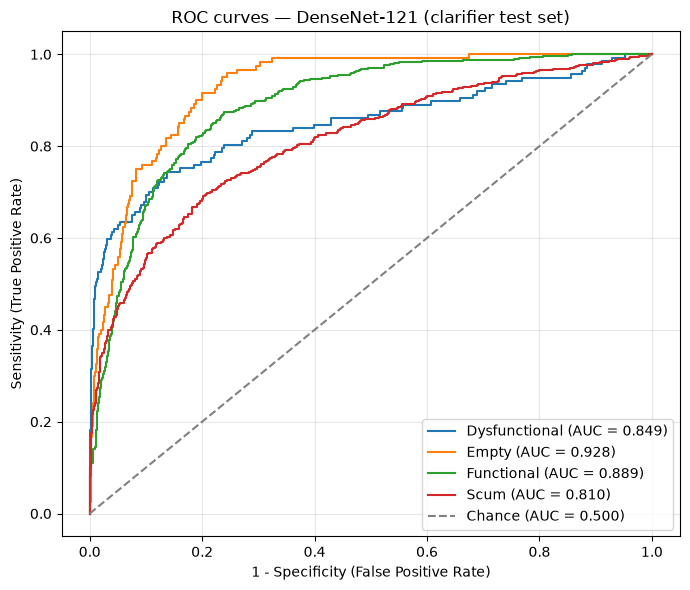

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.849
  Empty          : 0.928
  Functional     : 0.889
  Scum           : 0.810

Mean AUC (over 4/4 classes with test examples): 0.869


(np.float64(0.6260162601626016),
 {'Dysfunctional': 0.8486287293600736,
  'Empty': 0.9284599311701082,
  'Functional': 0.8892385473507981,
  'Scum': 0.8101891421335865})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/clarifier_aug/results_clarifier_densenet121_CapeFlats.pkl
Saved model weights to ../models/clarifier_densenet121_cnn.pt
